# Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Define the path
path = "/content/drive/MyDrive/Tutorial Session"

# Change the current working directory
os.chdir(path)

# Verify you are in the right spot
print("Current Directory:", os.getcwd())
print("Files in folder:", os.listdir())

import json
with open('token_data.json','r') as f:
    token_dict = json.load(f)

HF_TOKEN = token_dict['HF_TOKEN']
OPENAI_TOKEN = token_dict['OPENAI_TOKEN']

# Replace the following with your own credentials
# HF_TOKEN =
# OPENAI_TOKEN =

from openai import OpenAI

# Initialize the client
client = OpenAI(api_key=OPENAI_TOKEN)

Mounted at /content/drive
Current Directory: /content/drive/MyDrive/ENAR Tutorial Session
Files in folder: ['token_data.json', 'data', 'wandb', '__pycache__', 'KMGPT_API.py', 'Section 1: Intro to LLM.ipynb', 'AutoCriteria Demo.ipynb', 'Demo Project.ipynb', 'Biostats Talk Slides.gslides', 'Section 2: Biomedical Domain Adaptation.ipynb', 'Slides.gslides', 'Biostats Talk Slides 2.gslides', 'Section 3: Autonomous Agents.ipynb']


# Module 1: Structured Output

## Example: Image Quality Detection

We start by building a simple agent to detect the quality of a Kaplan-Meier Plot.

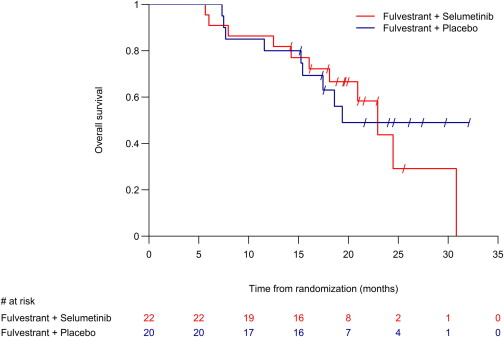

Ref: Zaman, Khalil, et al. "Fulvestrant with or without selumetinib, a MEK 1/2 inhibitor, in breast cancer progressing after aromatase inhibitor therapy: a multicentre randomised placebo-controlled double-blind phase II trial, SAKK 21/08." European journal of cancer 51.10 (2015): 1212-1220.

We prompt the system to check the following:
* If the figure is a Kaplan-Meier Plot
* If both axis are complete
* If the figure contains a risk table

In [ ]:
system_prompt = """
You are an expert biomedical data abstractor specializing in survival analysis.
Your task is to analyze the provided image and verify three specific quality criteria:

1. **KM Plot Identification**: Determine if the image is a Kaplan-Meier (KM) survival plot.
2. **Axis Completeness**: Check if both the X-axis (Time) and Y-axis (Survival Probability/Percentage) are present, labeled, and have visible scales.
3. **Risk Table Presence**: Identify if the figure includes a "Number at Risk" table (usually located below the X-axis).
"""

Next we need to load the image and convert it to base64 encode, which is the standard encoding for image input into LLMs.

In [ ]:
import base64
import os

# Function to encode local image to base64
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# Encode your image
base64_image = encode_image("data/example_km_plot1.jpg")

Then we proceed to check the image's quality

In [ ]:
# Define the Query
query = "Analyze this image according to the system instructions."

# API Call
response = client.chat.completions.create(
    model="gpt-4o",  # Must use a multimodal model
    messages=[
        {"role": "system", "content": system_prompt},
        {
            "role": "user",
            "content": [
                {"type": "text", "text": query},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"
                    }
                }
            ]
        }
    ],
    temperature=0
)

print(response.choices[0].message.content)

1. **KM Plot Identification**: Yes, this image is a Kaplan-Meier survival plot.

2. **Axis Completeness**: 
   - The X-axis is labeled "Time from randomization (months)" and has a visible scale.
   - The Y-axis is labeled "Overall survival" and has a visible scale.

3. **Risk Table Presence**: Yes, there is a "Number at Risk" table present below the X-axis.


Though these results are correct, they are not well formatted so that we cannot use them as stable machine-readable signals for downsteam workflow.

Let's try to define the output format as well:

In [ ]:
formatted_system_prompt = """
You are an expert biomedical data abstractor specializing in survival analysis.
Your task is to analyze the provided image and verify three specific quality criteria:

1. **KM Plot Identification**: Determine if the image is a Kaplan-Meier (KM) survival plot.
2. **Axis Completeness**: Check if both the X-axis (Time) and Y-axis (Survival Probability/Percentage) are present, labeled, and have visible scales.
3. **Risk Table Presence**: Identify if the figure includes a "Number at Risk" table (usually located below the X-axis).

Output your findings strictly in JSON format with the following keys:
- 'is_km_plot': boolean
- 'axes_complete': boolean
- 'has_risk_table': boolean
"""

In [ ]:

# Define the Query
query = "Analyze this image according to the system instructions."

# API Call
response = client.chat.completions.create(
    model="gpt-4o",  # Must use a multimodal model
    messages=[
        {"role": "system", "content": formatted_system_prompt},
        {
            "role": "user",
            "content": [
                {"type": "text", "text": query},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"
                    }
                }
            ]
        }
    ],
    temperature=0
)

print(response.choices[0].message.content)

```json
{
  "is_km_plot": true,
  "axes_complete": true,
  "has_risk_table": true
}
```


To ensure the output format is stable, we could further enhance it by using the **JOSN Schema**.

In [ ]:
formatted_system_prompt = """
You are an expert biomedical data abstractor specializing in survival analysis.
Your task is to analyze the provided image and verify three specific quality criteria:

1. KM Plot Identification: Determine if the image is a Kaplan-Meier (KM) survival plot.
2. Axis Completeness: Check if both the X-axis (Time) and Y-axis (Survival Probability/Percentage)
   are present, labeled, and have visible scales.
3. Risk Table Presence: Identify if the figure includes a "Number at Risk" table.

Return ONLY a JSON object that strictly conforms to the provided JSON Schema.
"""

# Define the schema with desired format
km_plot_schema = {
    "name": "km_plot_qc_output",
    "strict": True,
    "schema": {
        "$schema": "https://json-schema.org/draft/2020-12/schema",
        "title": "KM Plot Quality Criteria Output",
        "type": "object",
        "additionalProperties": False, # Important: Set to False in almost all cases
        "required": [
            "is_km_plot",
            "axes_complete",
            "has_risk_table"
        ],
        "properties": {
            "is_km_plot": {
                "type": "boolean",
                "description": "True if the image is a Kaplan-Meier survival plot."
            },
            "axes_complete": {
                "type": "boolean",
                "description": "True if both X and Y axes are present, labeled, and have visible scales."
            },
            "has_risk_table": {
                "type": "boolean",
                "description": "True if a Number-at-Risk table is present."
            }
        }
    }
}

In [ ]:
response = client.chat.completions.create(
    model="gpt-4o",  # multimodal model
    temperature=0,
    response_format={
        "type": "json_schema",
        "json_schema": km_plot_schema
    },
    messages=[
        {
            "role": "system",
            "content": formatted_system_prompt
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Analyze this image according to the system instructions."},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"
                    }
                }
            ]
        }
    ]
)

result = response.choices[0].message.content
print(result)

{"is_km_plot":true,"axes_complete":true,"has_risk_table":true}


# Module 2: Autonomous Agent

## Example: Tool Calling Agent

Next we will build an tool for AI to fit survival data via KM estimator.

### Install Dependencies

In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 15.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=98fdc868d18da3076e48d4223487f964b3c7cb77b1ce98f6dd8a39fe08934204
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


### Step 1: Define Tool Function

In [ ]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import pandas as pd

def fit_km_estimator(time, event):
    """
    Fits a Kaplan-Meier estimator to the provided data and returns a plot.

    Args:
        time (list): List of durations until the event or censoring.
        event (list): List of binary event indicators (1 if event occurred, 0 if censored).
    """
    # Initialize the fitter
    kmf = KaplanMeierFitter()

    # Fit the data
    kmf.fit(durations=time, event_observed=event)

    # Create the plot
    plt.figure(figsize=(10, 6))
    kmf.plot_survival_function()
    plt.title('Kaplan-Meier Survival Curve')
    plt.xlabel('Time')
    plt.ylabel('Survival Probability')
    plt.grid(True)

    # Display the plot
    plt.show()

    return "Kaplan-Meier model fitted and plot generated successfully."

### Step 2: Tool Definition for the Agent

In [ ]:
fit_km_estimator_schema = {
    "name": "fit_km_estimator",
    "strict": True,
    "schema": {
        "$schema": "https://json-schema.org/draft/2020-12/schema",
        "title": "Kaplan-Meier Estimator Input",
        "type": "object",
        "additionalProperties": False,
        "required": [
            "toolname",
            "time",
            "event"
        ],
        "properties": {
            "toolname": {
                "type": "string",
                "description": "The name of the function to call (e.g., 'fit_km_estimator')."
            },
            "time": {
                "type": "array",
                "items": {
                    "type": "number"
                },
                "description": "List of time durations until the event or censoring."
            },
            "event": {
                "type": "array",
                "items": {
                    "type": "integer"
                },
                "description": "List of binary indicators (1 for event occurred, 0 for censored)."
            }
        }
    }
}


km_estimator_system_prompt = '''
**Role:** You are a specialized Medical Data Assistant capable of performing survival analysis.
Your primary task is to interpret user requests involving time-to-event data and format them for the `fit_km_estimator` tool.

**Available Tools:**
1. `fit_km_estimator`:
   - Purpose: Fits a Kaplan-Meier model and generates a survival curve plot.
   - Required Arguments:
     - `time`: (List of floats/ints) Durations until event or censoring.
     - `event`: (List of ints) Binary status (1 for event occurred, 0 for censored).

**Operating Instructions:**
- When a user provides survival data (even in messy text or JSON), extract the 'time' and 'event' arrays.
- Ensure both arrays are of equal length before calling the tool.
- If the user provides data but does not specify which column is 'time' or 'event', use your medical knowledge to infer (e.g., "Months" is likely time, "Status" is likely event).
- If data is missing or improperly formatted, ask the user for clarification instead of guessing.

**Output Format:**
Respond ONLY with a tool call in the specified JSON schema if data is present. Otherwise just return None for toolname.
'''

### Step 3: Define the Tool-Calling Agent Logic

Before passing the final answer from LLM, we first define an intermediate step of checking if any function calling is triggered.

In [ ]:
import json
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

class SurvivalAgent:
    def __init__(self, client, system_prompt, tool_schema):
        self.client = client
        self.system_prompt = system_prompt
        self.tool_schema = tool_schema
        # Registry of executable functions
        self.functions = {
            "fit_km_estimator": self._execute_km_estimator
        }

    def _execute_km_estimator(self, time, event):
        fit_km_estimator(time, event)

        return {"status": "success", "message": "Plot generated"}

    def call_llm(self, query, image_data=None):
        """Sends query to LLM and parses the structured output."""
        content = [{"type": "text", "text": query}]

        # Handle multimodal input if an image is provided
        if image_data:
            content.append({
                "type": "image_url",
                "image_url": {"url": f"data:image/png;base64,{image_data}"}
            })

        response = self.client.chat.completions.create(
            model="gpt-4o",
            temperature=0,
            response_format={
                "type": "json_schema",
                "json_schema": self.tool_schema
            },
            messages=[
                {"role": "system", "content": self.system_prompt},
                {"role": "user", "content": content}
            ]
        )

        # Parse the structured JSON response
        return json.loads(response.choices[0].message.content)

    def run(self, query, image_data=None):
        """Main entry point: Parse -> Check Tool -> Execute."""
        structured_data = self.call_llm(query, image_data)
        print("LLM Raw Response:")
        print(structured_data)
        tool_to_call = structured_data.get("toolname")

        # Trigger function based on toolname
        if tool_to_call in self.functions:
            print(f"Agent: Triggering tool '{tool_to_call}'...")
            # Unpack time and event from the LLM's parsed arguments
            result = self.functions[tool_to_call](
                time=structured_data["time"],
                event=structured_data["event"]
            )
            return result
        else:
            return f"Error: Tool '{tool_to_call}' not recognized."

### Step 4: Create Pseudo Inputs

In [ ]:
example_survival_data = '''{
    "time": [2, 4, 6, 8, 9, 12, 16, 17, 19, 22, 24, 26, 30],
    "event": [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1]
}
'''

query = f'Help me fit a survial curve via KM estimator for these data. \n Data : {example_survival_data}'

### Step 5: Initialize Agent and Run

In [ ]:
agent = SurvivalAgent(
    client=client,
    system_prompt=km_estimator_system_prompt,
    tool_schema=fit_km_estimator_schema
)

Case 1: We use the well-formatted data to request a KM Plot

LLM Raw Response:
{'toolname': 'fit_km_estimator', 'time': [2, 4, 6, 8, 9, 12, 16, 17, 19, 22, 24, 26, 30], 'event': [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1]}
Agent: Triggering tool 'fit_km_estimator'...


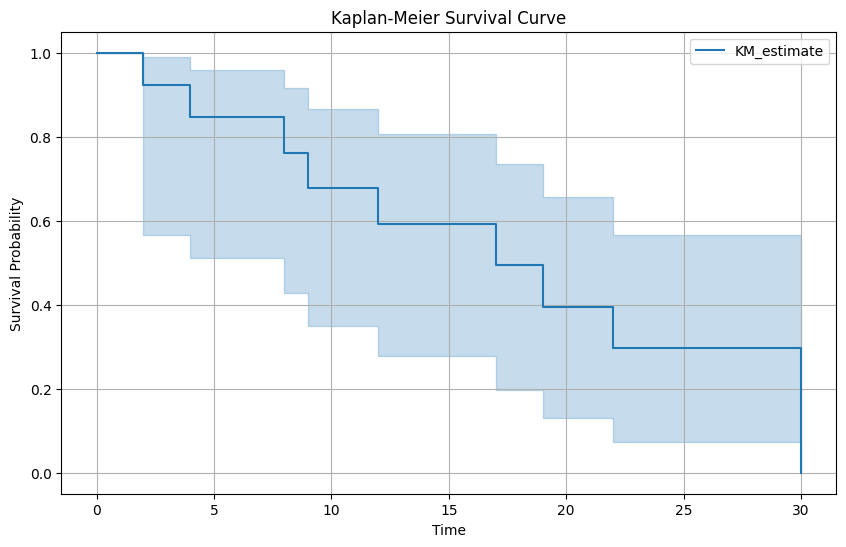

{'status': 'success', 'message': 'Plot generated'}


In [ ]:
final_result = agent.run(query)
print(final_result)

Case 2: Irrelvant Request (Failed to trigger the tool calling)

In [ ]:
final_result = agent.run("How's the weather today?")
final_result

"Error: Tool '' not recognized."